# Reward search for dense traffic

This notebook performs a **systematic reward search** for `highway-v0` under **dense traffic**.

Goal:
- search reward weights automatically instead of only changing them by hand
- train several DQN candidates on `vehicles_density = 2.0`
- evaluate them on dense traffic
- log all results to a CSV
- select the best candidate with a **safety-first score**


In [1]:
import os, sys, random, time, math
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import highway_env

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

DENSE_BASELINE_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config is not None:
        env.unwrapped.config.update(config)
    return env

tmp_env = make_env(DENSE_BASELINE_CONFIG)
tmp_obs, _ = tmp_env.reset()
OBS_SIZE = tmp_obs.flatten().shape[0]
N_ACTIONS = tmp_env.action_space.n
tmp_env.close()

print("OBS_SIZE:", OBS_SIZE)
print("N_ACTIONS:", N_ACTIONS)

OBS_SIZE: 50
N_ACTIONS: 5


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity, obs_size):
        self.capacity = capacity
        self.pos = 0
        self.full = False
        self.states = np.zeros((capacity, obs_size), dtype=np.float32)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_size), dtype=np.float32)

    def push(self, state, action, reward, done, next_state):
        self.states[self.pos] = state
        self.actions[self.pos] = action
        self.rewards[self.pos] = reward
        self.dones[self.pos] = done
        self.next_states[self.pos] = next_state
        self.pos = (self.pos + 1) % self.capacity
        if self.pos == 0:
            self.full = True

    def __len__(self):
        return self.capacity if self.full else self.pos

    def sample(self, batch_size):
        max_idx = self.capacity if self.full else self.pos
        idxs = np.random.choice(max_idx, size=batch_size, replace=False)
        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.dones[idxs],
            self.next_states[idxs],
        )

class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

class DQN:
    def __init__(
        self,
        obs_size,
        n_actions,
        gamma=0.99,
        batch_size=64,
        buffer_capacity=20_000,
        update_target_every=200,
        epsilon_start=0.9,
        epsilon_min=0.05,
        epsilon_decay=2000,
        learning_rate=1e-3,
        hidden_size=128,
        device=None
    ):
        self.device = device or torch.device("cpu")
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.update_target_every = update_target_every
        self.epsilon = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_steps = 0

        self.buffer = ReplayBuffer(buffer_capacity, obs_size)
        self.q_net = QNet(obs_size, n_actions, hidden_size).to(self.device)
        self.target_net = deepcopy(self.q_net)
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

    def get_action(self, state, epsilon=None):
        if epsilon is None:
            epsilon = self.epsilon
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        state_t = torch.FloatTensor(state.flatten()).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return q_values.argmax(dim=1).item()

    def update(self, state, action, reward, terminated, next_state):
        self.buffer.push(
            np.asarray(state.flatten(), dtype=np.float32),
            action,
            reward,
            float(terminated),
            np.asarray(next_state.flatten(), dtype=np.float32),
        )

        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, dones, next_states = self.buffer.sample(self.batch_size)
        states_t = torch.from_numpy(states).to(self.device)
        next_states_t = torch.from_numpy(next_states).to(self.device)
        actions_t = torch.from_numpy(actions).unsqueeze(1).to(self.device)
        rewards_t = torch.from_numpy(rewards).to(self.device)
        dones_t = torch.from_numpy(dones).to(self.device)

        q_current = self.q_net(states_t).gather(1, actions_t).squeeze(1)

        with torch.no_grad():
            q_next = self.target_net(next_states_t).max(dim=1).values
            q_target = rewards_t + self.gamma * q_next * (1 - dones_t)

        loss = self.loss_fn(q_current, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.n_steps += 1
        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.epsilon = self.epsilon_min + (
            (self.epsilon_start - self.epsilon_min) * np.exp(-self.n_steps / self.epsilon_decay)
        )
        return float(loss.item())

In [ ]:
def evaluate_agent_for_training(agent, config, eval_seeds=None, epsilon=0.0):
    if eval_seeds is None:
        eval_seeds = list(range(10))
    rewards = []
    for seed in eval_seeds:
        env_eval = make_env(config)
        obs, _ = env_eval.reset(seed=seed)
        done = False
        total_r = 0.0
        while not done:
            action = agent.get_action(obs, epsilon=epsilon)
            obs, r, terminated, truncated, _ = env_eval.step(action)
            total_r += r
            done = terminated or truncated
        rewards.append(total_r)
        env_eval.close()
    return np.array(rewards)

def train_dqn(agent, config, n_episodes=300, eval_every=50, verbose=True):
    episode_rewards = []
    eval_steps = []
    eval_means = []
    eval_stds = []
    all_losses = []

    env_train = make_env(config)

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=ep)
        done = False
        ep_reward = 0.0

        while not done:
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, _ = env_train.step(action)
            loss = agent.update(obs, action, reward, terminated, next_obs)
            if loss is not None:
                all_losses.append(loss)
            obs = next_obs
            ep_reward += reward
            done = terminated or truncated

        episode_rewards.append(ep_reward)

        if verbose and ((ep + 1) % 25 == 0 or ep == 0):
            print(f"Episode {ep+1}/{n_episodes} | reward={ep_reward:.3f} | epsilon={agent.epsilon:.3f}")

        if (ep + 1) % eval_every == 0:
            eval_r = evaluate_agent_for_training(agent, config, eval_seeds=list(range(10)))
            eval_means.append(float(eval_r.mean()))
            eval_stds.append(float(eval_r.std()))
            eval_steps.append(ep + 1)
            if verbose:
                print(f"  Eval @ {ep+1}: mean={eval_r.mean():.3f}, std={eval_r.std():.3f}")

    env_train.close()
    return episode_rewards, all_losses, eval_steps, eval_means, eval_stds

In [ ]:
def eval_agent(get_action, config, eval_seeds):
    n_sim = len(eval_seeds)

    env = make_env(config)
    env_copy = deepcopy(env)

    episode_rewards = np.zeros(n_sim)
    episode_lengths = np.zeros(n_sim)
    episode_distances = np.zeros(n_sim)
    episode_collisions = np.zeros(n_sim, dtype=bool)
    episode_actions = []

    for i, seed in enumerate(eval_seeds):
        state, _ = env_copy.reset(seed=seed)
        reward_sum = 0.0
        length = 0
        distance = 0.0
        actions = []
        done = False

        while not done:
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env_copy.step(action)

            reward_sum += reward
            length += 1

            dt = 1 / env_copy.unwrapped.config["simulation_frequency"]
            speed = env_copy.unwrapped.vehicle.speed
            distance += speed * dt

            done = terminated or truncated

        if terminated:
            episode_collisions[i] = True

        episode_rewards[i] = reward_sum
        episode_lengths[i] = length
        episode_distances[i] = distance
        episode_actions.append(actions)

    env_copy.close()
    env.close()
    return episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions

def compute_metrics(eval_output, n_actions):
    rewards, lengths, distances, collisions, actions = eval_output

    metrics = {
        "mean_reward": float(rewards.mean()),
        "std_reward": float(rewards.std()),
        "mean_episode_length": float(lengths.mean()),
        "std_episode_length": float(lengths.std()),
        "mean_distance": float(distances.mean()),
        "std_distance": float(distances.std()),
        "success_rate": float(100 * (~collisions).mean()),
        "collision_rate": float(100 * collisions.mean()),
    }

    all_actions = np.concatenate(actions) if len(actions) > 0 else np.array([], dtype=int)
    counts = np.bincount(all_actions, minlength=n_actions) if all_actions.size > 0 else np.zeros(n_actions, dtype=int)
    total_actions = counts.sum()

    for a in range(n_actions):
        metrics[f"action_count_{a}"] = int(counts[a])
        metrics[f"action_pct_{a}"] = float(100 * counts[a] / total_actions) if total_actions > 0 else 0.0

    return metrics

def safety_first_score(metrics):
    # Main search objective:
    # reward configs that both survive more and keep moving.
    return float((metrics["success_rate"] / 100.0) * metrics["mean_distance"])

In [ ]:
# Search settings
CHECKPOINT_DIR = "checkpoints"
RESULTS_DIR = "results"
SEARCH_CSV = os.path.join(RESULTS_DIR, "reward_search_dense.csv")
SEARCH_BEST_DIR = os.path.join(CHECKPOINT_DIR, "reward_search")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SEARCH_BEST_DIR, exist_ok=True)

USE_WARM_START = True
WARM_START_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "dqn_dense_baseline.pt")

# Search budget
N_SEARCH_RUNS = 6           
N_EPISODES = 250           
SEARCH_EVAL_SEEDS = list(range(30))
TRAIN_VERBOSE = True
SAVE_ALL_CHECKPOINTS = True

SEARCH_SPACE = {
    "collision_reward": (-10.0, -2.0),
    "high_speed_reward": (0.05, 0.60),
    "lane_change_reward": (-0.15, -0.02),
}

REFERENCE_CONFIGS = {
    "dense_baseline": {
        "collision_reward": -1.5,
        "high_speed_reward": 0.7,
        "lane_change_reward": -0.02,
    },
    "dense_balanced": {
        "collision_reward": -3.0,
        "high_speed_reward": 0.45,
        "lane_change_reward": -0.05,
    },
    "dense_safety": {
        "collision_reward": -5.0,
        "high_speed_reward": 0.25,
        "lane_change_reward": -0.08,
    },
}

In [ ]:
RESULT_COLUMNS = [
    "candidate_id",
    "train_seed",
    "collision_reward",
    "high_speed_reward",
    "lane_change_reward",
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "std_episode_length",
    "mean_distance",
    "std_distance",
    "success_rate",
    "collision_rate",
    "score",
    "checkpoint_path",
    "warm_start_used",
    "notes",
]

def load_search_results():
    if os.path.exists(SEARCH_CSV):
        df = pd.read_csv(SEARCH_CSV)
        for col in RESULT_COLUMNS:
            if col not in df.columns:
                df[col] = None
        return df[RESULT_COLUMNS]
    return pd.DataFrame(columns=RESULT_COLUMNS)

def upsert_search_row(df, row):
    df = df[df["candidate_id"] != row["candidate_id"]]
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(SEARCH_CSV, index=False)
    return df

def sample_reward_config():
    cfg = dict(DENSE_BASELINE_CONFIG)
    cfg["collision_reward"] = float(np.round(np.random.uniform(*SEARCH_SPACE["collision_reward"]), 3))
    cfg["high_speed_reward"] = float(np.round(np.random.uniform(*SEARCH_SPACE["high_speed_reward"]), 3))
    cfg["lane_change_reward"] = float(np.round(np.random.uniform(*SEARCH_SPACE["lane_change_reward"]), 3))
    return cfg

def make_candidate_id(i, cfg):
    return (
        f"cand_{i:02d}"
        f"_c{cfg['collision_reward']}"
        f"_s{cfg['high_speed_reward']}"
        f"_l{cfg['lane_change_reward']}"
    ).replace(" ", "")

In [8]:
def maybe_warm_start(agent, checkpoint_path):
    if checkpoint_path is None:
        return False
    if not os.path.exists(checkpoint_path):
        print(f"Warm-start checkpoint not found: {checkpoint_path}")
        return False
    state_dict = torch.load(checkpoint_path, map_location=device)
    agent.q_net.load_state_dict(state_dict)
    agent.target_net.load_state_dict(state_dict)
    print(f"Warm-started from {checkpoint_path}")
    return True

def make_greedy_policy(agent):
    def get_action(obs):
        return agent.get_action(obs, epsilon=0.0)
    return get_action

def run_single_candidate(candidate_index, train_seed=None):
    cfg = sample_reward_config()
    candidate_id = make_candidate_id(candidate_index, cfg)
    if train_seed is None:
        train_seed = 1000 + candidate_index

    print("=" * 100)
    print("Candidate:", candidate_id)
    print("Config:", {
        "collision_reward": cfg["collision_reward"],
        "high_speed_reward": cfg["high_speed_reward"],
        "lane_change_reward": cfg["lane_change_reward"],
        "vehicles_density": cfg["vehicles_density"],
    })

    random.seed(train_seed)
    np.random.seed(train_seed)
    torch.manual_seed(train_seed)

    agent = DQN(
        obs_size=OBS_SIZE,
        n_actions=N_ACTIONS,
        device=device,
        gamma=0.99,
        batch_size=64,
        buffer_capacity=20_000,
        update_target_every=200,
        epsilon_start=0.9,
        epsilon_min=0.05,
        epsilon_decay=2000,
        learning_rate=1e-3,
    )

    warm_started = False
    if USE_WARM_START:
        warm_started = maybe_warm_start(agent, WARM_START_CHECKPOINT)

    start = time.time()
    ep_rewards, losses, eval_steps, eval_means, eval_stds = train_dqn(
        agent, cfg, n_episodes=N_EPISODES, eval_every=50, verbose=TRAIN_VERBOSE
    )
    train_time = time.time() - start
    print(f"Training time: {train_time/60:.2f} min")

    policy = make_greedy_policy(agent)
    eval_output = eval_agent(policy, cfg, SEARCH_EVAL_SEEDS)
    metrics = compute_metrics(eval_output, N_ACTIONS)
    score = safety_first_score(metrics)

    print("Search metrics:")
    print({
        "success_rate": metrics["success_rate"],
        "collision_rate": metrics["collision_rate"],
        "mean_distance": metrics["mean_distance"],
        "mean_reward": metrics["mean_reward"],
        "score": score,
    })

    checkpoint_path = os.path.join(SEARCH_BEST_DIR, f"{candidate_id}.pt")
    if SAVE_ALL_CHECKPOINTS:
        torch.save(agent.q_net.state_dict(), checkpoint_path)
        print("Saved checkpoint to", checkpoint_path)
    else:
        checkpoint_path = None

    row = {
        "candidate_id": candidate_id,
        "train_seed": train_seed,
        "collision_reward": cfg["collision_reward"],
        "high_speed_reward": cfg["high_speed_reward"],
        "lane_change_reward": cfg["lane_change_reward"],
        "mean_reward": metrics["mean_reward"],
        "std_reward": metrics["std_reward"],
        "mean_episode_length": metrics["mean_episode_length"],
        "std_episode_length": metrics["std_episode_length"],
        "mean_distance": metrics["mean_distance"],
        "std_distance": metrics["std_distance"],
        "success_rate": metrics["success_rate"],
        "collision_rate": metrics["collision_rate"],
        "score": score,
        "checkpoint_path": checkpoint_path,
        "warm_start_used": warm_started,
        "notes": "random reward search on dense traffic",
    }

    curves = {
        "episode_rewards": ep_rewards,
        "losses": losses,
        "eval_steps": eval_steps,
        "eval_means": eval_means,
        "eval_stds": eval_stds,
    }
    return row, curves


In [9]:
df_search = load_search_results()
all_curves = {}

for i in range(1, N_SEARCH_RUNS + 1):
    row, curves = run_single_candidate(i)
    df_search = upsert_search_row(df_search, row)
    all_curves[row["candidate_id"]] = curves

print("\nCurrent search results:")
df_search.sort_values(by=["score", "success_rate", "mean_distance"], ascending=False).reset_index(drop=True)

Candidate: cand_01_c-4.964_s0.061_l-0.048
Config: {'collision_reward': -4.964, 'high_speed_reward': 0.061, 'lane_change_reward': -0.048, 'vehicles_density': 2.0}
Warm-started from checkpoints\dqn_dense_baseline.pt
Episode 1/250 | reward=0.000 | epsilon=0.900
Episode 25/250 | reward=0.999 | epsilon=0.881
Episode 50/250 | reward=2.967 | epsilon=0.825
  Eval @ 50: mean=11.269, std=9.320
Episode 75/250 | reward=17.791 | epsilon=0.769
Episode 100/250 | reward=0.988 | epsilon=0.716
  Eval @ 100: mean=14.819, std=8.758
Episode 125/250 | reward=0.999 | epsilon=0.679
Episode 150/250 | reward=3.971 | epsilon=0.629
  Eval @ 150: mean=12.842, std=6.185
Episode 175/250 | reward=2.991 | epsilon=0.579
Episode 200/250 | reward=0.992 | epsilon=0.541
  Eval @ 200: mean=14.324, std=9.540
Episode 225/250 | reward=17.789 | epsilon=0.498
Episode 250/250 | reward=5.956 | epsilon=0.452
  Eval @ 250: mean=15.906, std=8.685
Training time: 16.17 min
Search metrics:
{'success_rate': 16.666666666666664, 'collision

,candidate_id,train_seed,collision_reward,high_speed_reward,lane_change_reward,mean_reward,std_reward,mean_episode_length,std_episode_length,mean_distance,std_distance,success_rate,collision_rate,score,checkpoint_path,warm_start_used,notes
0,cand_01_c-4.964_s0.061_l-0.048,1001,-4.964,0.061,-0.048,14.062355,9.297466,15.066667,9.135766,19.882534,12.301522,16.666667,83.333333,3.313756,checkpoints\reward_search\cand_01_c-4.964_s0.0...,True,random reward search on dense traffic
1,cand_04_c-7.454_s0.244_l-0.15,1004,-7.454,0.244,-0.15,12.755808,9.148713,14.033333,9.217676,18.568874,12.330688,13.333333,86.666667,2.47585,checkpoints\reward_search\cand_04_c-7.454_s0.2...,True,random reward search on dense traffic
2,cand_06_c-9.692_s0.51_l-0.11,1006,-9.692,0.51,-0.11,12.550046,8.495322,14.066667,8.698403,18.566524,11.661003,13.333333,86.666667,2.475536,checkpoints\reward_search\cand_06_c-9.692_s0.5...,True,random reward search on dense traffic
3,cand_02_c-9.994_s0.213_l-0.142,1002,-9.994,0.213,-0.142,12.699965,9.139851,13.833333,9.096092,18.256074,12.13968,13.333333,86.666667,2.434143,checkpoints\reward_search\cand_02_c-9.994_s0.2...,True,random reward search on dense traffic
4,cand_05_c-8.218_s0.192_l-0.073,1005,-8.218,0.192,-0.073,10.829377,7.799022,12.0,7.814516,16.163324,10.964367,6.666667,93.333333,1.077555,checkpoints\reward_search\cand_05_c-8.218_s0.1...,True,random reward search on dense traffic
5,cand_03_c-8.049_s0.125_l-0.134,1003,-8.049,0.125,-0.134,9.203351,6.775018,10.3,6.778151,14.164735,9.358763,3.333333,96.666667,0.472158,checkpoints\reward_search\cand_03_c-8.049_s0.1...,True,random reward search on dense traffic


In [10]:
df_search = load_search_results()
df_sorted = df_search.sort_values(by=["score", "success_rate", "mean_distance"], ascending=False).reset_index(drop=True)
df_sorted

,candidate_id,train_seed,collision_reward,high_speed_reward,lane_change_reward,mean_reward,std_reward,mean_episode_length,std_episode_length,mean_distance,std_distance,success_rate,collision_rate,score,checkpoint_path,warm_start_used,notes
0,cand_01_c-4.964_s0.061_l-0.048,1001,-4.964,0.061,-0.048,14.062355,9.297466,15.066667,9.135766,19.882534,12.301522,16.666667,83.333333,3.313756,checkpoints\reward_search\cand_01_c-4.964_s0.0...,True,random reward search on dense traffic
1,cand_04_c-7.454_s0.244_l-0.15,1004,-7.454,0.244,-0.150,12.755808,9.148713,14.033333,9.217676,18.568874,12.330688,13.333333,86.666667,2.475850,checkpoints\reward_search\cand_04_c-7.454_s0.2...,True,random reward search on dense traffic
2,cand_06_c-9.692_s0.51_l-0.11,1006,-9.692,0.510,-0.110,12.550046,8.495322,14.066667,8.698403,18.566524,11.661003,13.333333,86.666667,2.475536,checkpoints\reward_search\cand_06_c-9.692_s0.5...,True,random reward search on dense traffic
3,cand_02_c-9.994_s0.213_l-0.142,1002,-9.994,0.213,-0.142,12.699965,9.139851,13.833333,9.096092,18.256074,12.139680,13.333333,86.666667,2.434143,checkpoints\reward_search\cand_02_c-9.994_s0.2...,True,random reward search on dense traffic
4,cand_05_c-8.218_s0.192_l-0.073,1005,-8.218,0.192,-0.073,10.829377,7.799022,12.000000,7.814516,16.163324,10.964367,6.666667,93.333333,1.077555,checkpoints\reward_search\cand_05_c-8.218_s0.1...,True,random reward search on dense traffic
5,cand_03_c-8.049_s0.125_l-0.134,1003,-8.049,0.125,-0.134,9.203351,6.775018,10.300000,6.778151,14.164735,9.358763,3.333333,96.666667,0.472158,checkpoints\reward_search\cand_03_c-8.049_s0.1...,True,random reward search on dense traffic


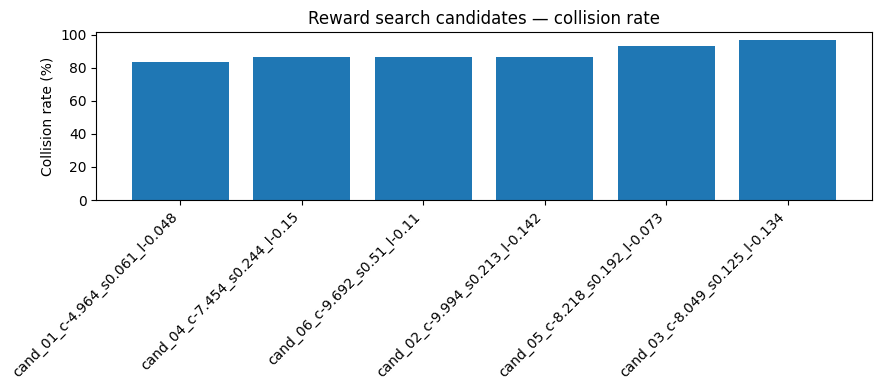

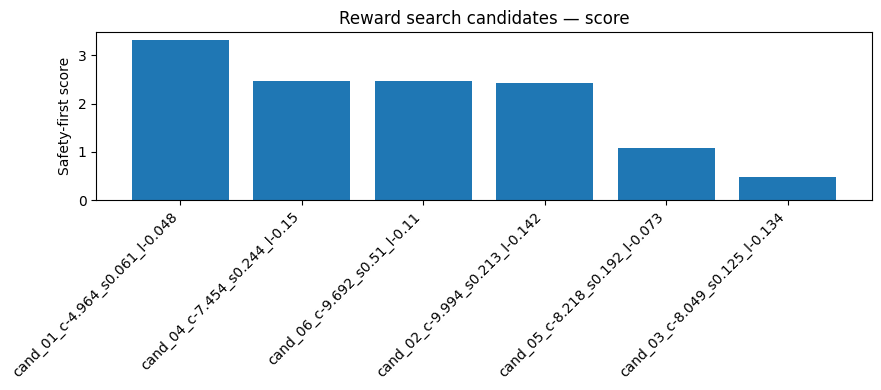

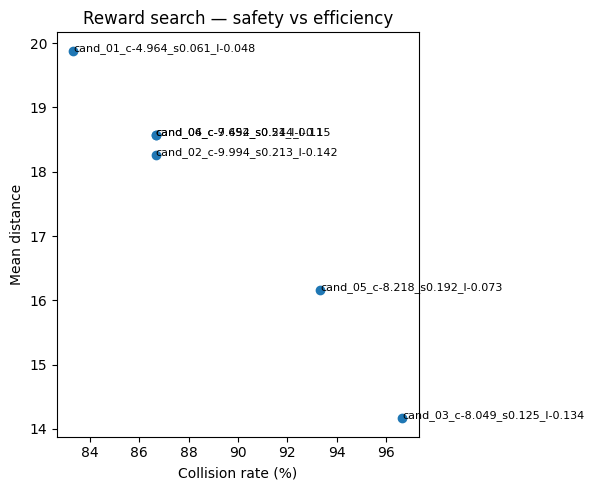

In [11]:
# Plots for search results
df_plot = load_search_results().sort_values(by="score", ascending=False)

plt.figure(figsize=(9,4))
plt.bar(df_plot["candidate_id"], df_plot["collision_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Collision rate (%)")
plt.title("Reward search candidates — collision rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.bar(df_plot["candidate_id"], df_plot["score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Safety-first score")
plt.title("Reward search candidates — score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(df_plot["collision_rate"], df_plot["mean_distance"])
for _, row in df_plot.iterrows():
    plt.text(row["collision_rate"], row["mean_distance"], row["candidate_id"], fontsize=8)
plt.xlabel("Collision rate (%)")
plt.ylabel("Mean distance")
plt.title("Reward search — safety vs efficiency")
plt.tight_layout()
plt.show()
